# Momentum + Value Strat: Quant Project Run 2

## Revamping Strategy to get better results

### 1. By changing my universe of tickers to the ones in S&P500 and 
### 2. Changing the time range of the data I get to 10 years.
### 3. Understanding my factors in depth and maybe eliminate correlatation between them
### 4. Eliminated some factors and introduce others (eg. value)
### 5. Change how portfolio is being constructed

In [1]:
# Our usual imports 
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import datetime
import pandas as pd

##### Below code is to keep the outputs short

* I am aware of the warnings and they are mostly to do with syntax used.
* Some functions in python seem to be deprecated and old syntax doesn't work anymore
* No need to fix now

In [2]:
import warnings
warnings.filterwarnings('ignore')

### First, lets change our universe of stocks

In [3]:
import requests
import pandas as pd

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
resp = requests.get(url, headers=headers)
resp.raise_for_status()
sp500_table = pd.read_html(resp.text)[0]
univ = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()

### Changing the time range

In [4]:
# Make datetime arrays consisting of monthly dates for the last 2 years
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=365*10)
dates = pd.date_range(start=start_date, end=end_date, freq='ME')
dates = dates.normalize()
dates

DatetimeIndex(['2016-04-30', '2016-05-31', '2016-06-30', '2016-07-31',
               '2016-08-31', '2016-09-30', '2016-10-31', '2016-11-30',
               '2016-12-31', '2017-01-31',
               ...
               '2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30',
               '2025-10-31', '2025-11-30', '2025-12-31', '2026-01-31',
               '2026-02-28', '2026-03-31'],
              dtype='datetime64[ns]', length=120, freq='ME')

### Defining Important functions used in signal generation

In [5]:
# defining our functions that we are going to use in our loop 

def get_momentum_scores(prices, lookback=252, skip=21):
    """12-month momentum excluding the most recent month."""

    if len(prices) < lookback + skip:
        return {}

    momentum_window = prices.iloc[-(lookback + skip):-skip]

    first = momentum_window.iloc[0]
    last = momentum_window.iloc[-1]

    momentum_scores = (last - first) / first # for now, this is how I calculate momentum score, I will change when I learn more

    return momentum_scores.dropna().to_dict()


def get_reversal_scores(prices, window):
    """Mean-reversion (reverse momentum) over a given window (in trading days)."""

    if len(prices) < window:
        return {}

    reversal_window = prices.iloc[-window:]

    first = reversal_window.iloc[0]
    last = reversal_window.iloc[-1]

    reversal_scores = -((last - first) / first)

    return reversal_scores.dropna().to_dict()

def get_value_scores(tickers):
    value_scores = {}

    for ticker in tickers:
        try:
            stock = yf.Ticker(ticker)
            info = stock.info

            ev = info.get("enterpriseValue", None)
            ebitda = info.get("ebitda", None)

            if ev and ebitda and ev != 0:
                value_scores[ticker] = ebitda / ev  # proxy for EBIT/EV

        except:
            continue

    return value_scores

#### Disregard the earning functions, 

* they are a waste of time as I could've replaced my earning score with EPS from stock data

In [6]:

def get_earnings_history(tickers):

    earnings_data = {}

    for ticker in tickers:
        stock = yf.Ticker(ticker)
        earnings = stock.get_earnings_dates(limit=40)

        if not earnings.empty:
            # Ensure the earnings index is timezone-naive so it can be compared to naive timestamps in `dates`.
            # yfinance sometimes returns timezone-aware timestamps (e.g. America/New_York).
            if getattr(earnings.index, "tz", None) is not None:
                earnings.index = earnings.index.tz_convert(None)

            earnings["surprise"] = (
                (earnings["Reported EPS"] - earnings["EPS Estimate"]) /
                earnings["EPS Estimate"].abs()
            )

            earnings_data[ticker] = earnings["surprise"]

    return earnings_data

def compute_earnings_score(earnings_series, current_date, lookback=4):

    past = earnings_series[earnings_series.index <= current_date].dropna()

    if len(past) < lookback:
        return None

    return float(past.head(lookback).mean())

def build_earnings_factor(tickers, dates):

    earnings_data = get_earnings_history(tickers)

    factor = pd.DataFrame(index=dates, columns=tickers)

    for date in dates:
        for ticker in tickers:

            if ticker in earnings_data:
                score = compute_earnings_score(
                    earnings_data[ticker],
                    date
                )

                factor.loc[date, ticker] = score

    return factor


### Downloading prices for stocks in SP500

In [7]:
prices = yf.download(univ, start="2015-01-01", end=end_date, auto_adjust=False)['Adj Close']
prices

[*********************100%***********************]  503 of 503 completed

7 Failed downloads:
['VLO', 'DVN', 'SBAC']: ConnectionError('Failed to perform, curl: (56) Recv failure: Connection was reset. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
['BSX', 'TRV', 'PSX']: SSLError('Failed to perform, curl: (35) Recv failure: Connection was reset. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
['TTWO']: ConnectionError('Failed to perform, curl: (55) Recv failure: Connection was reset. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,36.970360,24.214897,41.755466,NaN,36.235119,18.539352,73.628212,72.339996,44.216038,37.381664,...,23.302095,125.731468,25.351807,57.533413,33.037384,NaN,42.024685,99.672630,77.430000,39.581661
2015-01-05,36.277626,23.532719,40.969669,NaN,36.243191,18.428413,72.385071,71.980003,43.411972,36.088181,...,23.302095,123.591583,25.064043,55.959206,30.981232,NaN,41.170837,103.390755,76.339996,39.344048
2015-01-06,35.712494,23.534939,40.766884,NaN,35.831604,18.469618,71.862953,70.529999,42.392937,35.376766,...,23.276281,120.955208,25.197399,55.661709,30.799025,NaN,40.665482,102.514343,75.790001,38.960197
2015-01-07,36.186481,23.864948,42.414536,NaN,36.122128,18.577387,73.371323,71.110001,42.838776,35.908531,...,23.347277,124.507462,25.414982,56.225704,31.041952,NaN,42.013065,105.063911,77.720001,39.764439
2015-01-08,37.271160,24.781895,42.858131,NaN,36.864605,18.900694,74.490150,72.919998,43.595070,35.383961,...,23.598940,126.005424,25.709768,57.161572,31.276194,NaN,42.744934,106.179359,79.379997,40.376770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-07,113.879997,253.500000,206.369995,124.970001,101.830002,96.919998,195.640900,240.139999,327.410004,72.150002,...,24.020000,100.430000,80.540001,163.910004,124.269997,59.970001,156.929993,91.400002,212.509995,116.800003
2026-04-08,116.919998,258.899994,211.589996,131.399994,103.559998,98.599998,192.209991,239.309998,346.209991,71.720001,...,24.900000,105.239998,81.459999,156.220001,127.970001,62.830002,160.429993,93.010002,221.139999,119.750000
2026-04-09,115.389999,260.489990,212.399994,129.160004,102.720001,98.839996,186.029999,229.940002,351.359985,70.349998,...,24.820000,104.889999,82.769997,155.039993,129.399994,62.689999,160.789993,93.029999,223.070007,119.989998


### Getting monthly returns for computing volatility weights

* After using volatility weights, my results were worse so I removed the vol weights
* Since this step falls in portfolio construction, I am able to change it however I want.

##### Can disregard for the moment

In [8]:
# Get prices from start date to end date using prices dataframe above
# new_prices = yf.download(univ, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

monthly_prices = prices.resample('ME').last()
#monthly_prices = monthly_prices.iloc[:-1]
returns = monthly_prices.pct_change()

returns.index = returns.index.normalize()
#returns = returns[weight_df.columns]
returns


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-28,0.117553,0.100776,0.002485,NaN,0.058311,0.020528,0.071403,0.127905,0.130982,0.032971,...,-0.012492,-0.027403,-0.059952,0.020435,0.051083,NaN,0.122164,0.073952,0.090942,0.078633
2015-03-31,-0.013212,-0.031372,-0.032397,NaN,-0.021955,0.041244,0.040653,-0.065234,0.076187,-0.010025,...,-0.055824,-0.116632,-0.004070,-0.039982,-0.019047,NaN,-0.029466,-0.022035,-0.003624,0.004340
2015-04-30,-0.004332,0.005786,0.113705,NaN,0.007069,-0.014935,-0.000524,0.028672,-0.018412,0.031223,...,-0.049472,-0.117652,-0.025855,0.027882,0.057110,NaN,0.097720,-0.065350,0.014991,-0.038675
2015-05-31,-0.004351,0.045339,0.029848,NaN,0.046962,0.052900,0.036589,0.039837,0.105580,0.086948,...,0.033323,-0.089450,0.004129,-0.016771,-0.008376,NaN,0.048278,0.040733,0.190704,0.120441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31,-0.113550,-0.025067,0.003470,0.160099,-0.028006,0.021295,0.073200,0.093275,0.025695,-0.053507,...,0.066637,-0.064890,-0.093532,0.038130,-0.031919,-0.025599,-0.007921,-0.075482,-0.039288,-0.018412
2026-01-31,-0.014557,-0.045538,-0.016131,-0.046788,-0.123205,0.001251,-0.017369,-0.162119,0.146313,0.170812,...,0.088223,-0.107039,0.029786,0.175004,0.012410,-0.071593,0.027895,-0.031695,-0.032287,-0.003712
2026-02-28,-0.093164,0.019066,0.040671,0.044369,0.064501,0.042795,-0.208314,-0.105166,0.144461,0.033433,...,-0.048487,0.009083,0.095977,0.085689,-0.057088,0.054112,0.086399,0.130585,-0.046898,0.050313


### Computing Signals

In [9]:
# empty dateframe with dates as index and columns as tickers, to store signals for each date and ticker
signals_df = pd.DataFrame(index=dates, columns=univ, dtype=float)

# prices = yf.download(univ, start="2015-01-01", end="2026-02-28", auto_adjust=False)['Adj Close']
# Earnings changes only quarterly so compute once and reuse inside the loop

# earnings_scores = build_earnings_factor(univ, dates)

# computing value scores outside since I don't have access to financial data 
# for each date and will need to get new APIs for this
# For now, since I am learning the quant pipeline to testing strategies, this is good enough.
# Warning: Look-ahead bias is introduced here but I have no way to fix it at the moment
value_scores = get_value_scores(univ)
value_s = pd.Series(value_scores)
value_z = (value_s - value_s.mean()) / value_s.std()

sorted_pscores = {}

vol = returns.rolling(3).std()

for date in dates:
    prices_until_date = prices.loc[:date]

    # Need enough history for the momentum window (12m) plus the skip month
    if len(prices_until_date) < 252 + 21:
        continue

    # Momentum Stuff
    momentum_scores = get_momentum_scores(prices_until_date)
    momentum_s = pd.Series(momentum_scores)
    momentum_z = (momentum_s - momentum_s.mean()) / momentum_s.std()
    
    # Reveral Stuff
    # reversal_scores_1m = get_reversal_scores(prices_until_date, 21)
    # reversal_scores_2m = get_reversal_scores(prices_until_date, 42)
    # reversal_scores_3m = get_reversal_scores(prices_until_date, 63)
    # Combine the reversal scores into a single score by averaging the 3, 2, and 1 month scores
    # combined_reversal = (
    #    pd.Series(reversal_scores_1m) +
    #    pd.Series(reversal_scores_2m) +
    #    pd.Series(reversal_scores_3m)
    #) / 3
    # reversal_z = (combined_reversal - combined_reversal.mean()) / combined_reversal.std()

    # Earnings Stuff
    # earnings_row = earnings_scores.loc[date].dropna()
    # earnings_z = (earnings_row - earnings_row.mean()) / earnings_row.std()
        
    # Compute pscore
    pscores = {}
    for ticker in univ:
        m_score =  momentum_z.get(ticker, 0)
        # r_score = 50 * reversal_z.get(ticker, 0)
        # e_score = 15 * earnings_z.get(ticker, 0)
        # v_score = value_z.get(ticker, 0)
        pscores[ticker] = m_score # +  v_score # r_score # + e_score +  

    # sorted_by_score = dict(sorted(pscores.items(), key=lambda item: item[1], reverse=True))
    # sorted_pscores[date] = sorted_by_score

    # Generate long/short/neutral signals (top/bottom 20%)
    # n = len(sorted_by_score)
    # n_rank = max(1, int(np.ceil(n * 0.2)))
    # long_tickers = list(sorted_by_score.keys())[:n_rank]
    # short_tickers = list(sorted_by_score.keys())[-n_rank:]  

    # for ticker in univ:
    #    if ticker in long_tickers:
    #        signals_df.loc[date, ticker] = 1
    #    elif ticker in short_tickers:
    #        signals_df.loc[date, ticker] = -1
    #    else:
    #        signals_df.loc[date, ticker] = 0
    pscore_series = pd.Series(pscores)
    sorted_pscores[date] = pscore_series.sort_values(ascending=False).to_dict()

    # Continuous weights
    ranks = pscore_series.rank(pct=True)
    
    # instead of longing everythat is positive and shorting everything that is negetive
    # I only long top 20% and short bottom 20% and give 0 weight to the rest
    # weights = ranks - 0.5
    # weights = weights - weights.mean()
    
    # Long the top 10% and short the bottom 10%, and give 0 weight to the rest, then normalize so that the sum of long weights is 1 and the sum of short weights is -1
    long_mask = ranks >= 0.9
    short_mask = ranks <= 0.1
    weights = pd.Series(0, index=pscore_series.index)
    weights[long_mask] = ranks[long_mask] - 0.5
    weights[short_mask] = ranks[short_mask] - 0.5
    
    # Normalize long and short weights separately
    weights[long_mask] = weights[long_mask] / weights[long_mask].sum()
    weights[short_mask] = weights[short_mask] / weights[short_mask].abs().sum()
    
    # optional vol scaling
    # vol_row = vol.loc[date]
    # weights = weights / vol_row
    # NOW apply volatility scaling
    
    # revamped volatily scaling
    # vol_row = vol.loc[date].replace(0, np.nan)

    # weights = weights / vol_row
    # weights = weights.replace([np.inf, -np.inf], np.nan).fillna(0)

    # Disregard below normalization
    # final normalization to ensure weights sum to 1 in absolute value
    # weights = weights / weights.abs().sum()

    # Store weights
    for ticker in univ:
        signals_df.loc[date, ticker] = weights.get(ticker, 0)


### Alternative Code for generating signals

* Supposedly much faster

In [10]:
'''
signals_df = pd.DataFrame(index=dates, columns=univ, dtype=float)

value_scores = get_value_scores(univ)
value_s = pd.Series(value_scores, index=univ, dtype=float)
value_z = (value_s - value_s.mean()) / value_s.std()

# Example momentum precompute:
# 12-month momentum skipping most recent month
momentum = prices.shift(21) / prices.shift(252) - 1

sorted_pscores = {}

for date in dates:
    # skip dates without enough history
    if pd.isna(momentum.loc[date]).all():
        continue

    momentum_s = momentum.loc[date].reindex(univ)
    momentum_z = (momentum_s - momentum_s.mean()) / momentum_s.std()

    # vectorized pscore
    pscore_series = momentum_z.add(value_z, fill_value=0).fillna(0)

    # only keep if you actually need this
    sorted_pscores[date] = pscore_series.sort_values(ascending=False).to_dict()

    ranks = pscore_series.rank(pct=True)

    long_mask = ranks >= 0.9
    short_mask = ranks <= 0.1

    weights = pd.Series(0.0, index=pscore_series.index)
    weights.loc[long_mask] = ranks.loc[long_mask] - 0.5
    weights.loc[short_mask] = ranks.loc[short_mask] - 0.5

    if long_mask.any():
        weights.loc[long_mask] /= weights.loc[long_mask].sum()
    if short_mask.any():
        weights.loc[short_mask] /= weights.loc[short_mask].abs().sum()

    signals_df.loc[date] = weights.reindex(univ, fill_value=0)
'''

'\nsignals_df = pd.DataFrame(index=dates, columns=univ, dtype=float)\n\nvalue_scores = get_value_scores(univ)\nvalue_s = pd.Series(value_scores, index=univ, dtype=float)\nvalue_z = (value_s - value_s.mean()) / value_s.std()\n\n# Example momentum precompute:\n# 12-month momentum skipping most recent month\nmomentum = prices.shift(21) / prices.shift(252) - 1\n\nsorted_pscores = {}\n\nfor date in dates:\n    # skip dates without enough history\n    if pd.isna(momentum.loc[date]).all():\n        continue\n\n    momentum_s = momentum.loc[date].reindex(univ)\n    momentum_z = (momentum_s - momentum_s.mean()) / momentum_s.std()\n\n    # vectorized pscore\n    pscore_series = momentum_z.add(value_z, fill_value=0).fillna(0)\n\n    # only keep if you actually need this\n    sorted_pscores[date] = pscore_series.sort_values(ascending=False).to_dict()\n\n    ranks = pscore_series.rank(pct=True)\n\n    long_mask = ranks >= 0.9\n    short_mask = ranks <= 0.1\n\n    weights = pd.Series(0.0, index=psco

## Huge Step in Signal generation

* In the first run after computing my signals, I actually realize that my strategy performs horribly.
* Meaning, the returns go down and returns decay.
* So, I had to reverse my calculated signals to produce positive return.

##### In Conclusion: My strategy actually signals negative returns 

In [11]:
# Reverse our strat since we have a negetive indicator
signals_df = -1 * signals_df
weight_df = signals_df.shift(1)
weight_df

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2016-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-05-31,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.000000,-0.0,-0.0,...,0.022080,-0.0,-0.000000,0.019602,-0.000000,-0.0,-0.0,0.019336,-0.0,-0.000000
2016-06-30,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.000000,-0.021426,-0.000000,-0.0,-0.0,...,0.021991,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.0,0.020664,-0.0,-0.000000
2016-07-31,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.000000,-0.021685,-0.000000,-0.0,-0.0,...,0.021726,-0.0,-0.000000,-0.000000,-0.018223,-0.0,-0.0,0.021903,-0.0,-0.000000
2016-08-31,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.000000,-0.021685,-0.000000,-0.0,-0.0,...,0.022080,-0.0,-0.000000,-0.000000,-0.018915,-0.0,-0.0,0.021991,-0.0,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,-0.0,-0.0,-0.0,-0.0,0.019425,0.019779,-0.000000,0.018805,-0.0,-0.0,...,-0.000000,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.0,-0.000000,-0.0,0.018097
2025-12-31,-0.0,-0.0,-0.0,-0.0,0.019690,0.019602,-0.018915,-0.000000,-0.0,-0.0,...,-0.000000,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.0,0.018451,-0.0,-0.000000
2026-01-31,-0.0,-0.0,-0.0,-0.0,0.018363,0.020487,-0.019175,-0.000000,-0.0,-0.0,...,-0.000000,-0.0,-0.000000,-0.017963,-0.000000,-0.0,-0.0,0.020664,-0.0,0.018009
2026-02-28,-0.0,-0.0,-0.0,-0.0,0.018805,0.018097,-0.019348,-0.000000,-0.0,-0.0,...,-0.000000,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.0,0.021195,-0.0,0.018540


### Performance Analysis

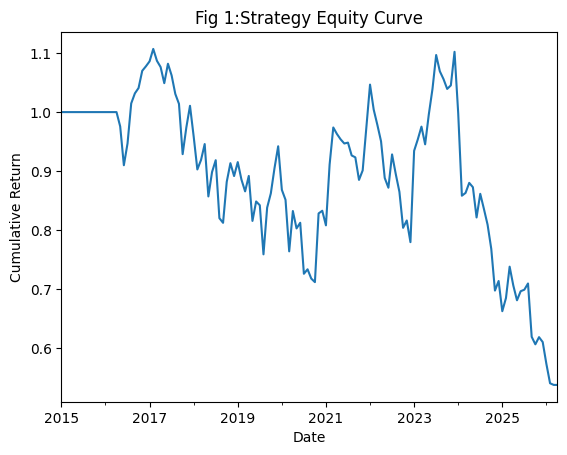

In [12]:
#new_prices = yf.download(univ, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

#monthly_prices = new_prices.resample('ME').last()
#monthly_prices = monthly_prices.iloc[:-1]
#returns = monthly_prices.pct_change()

weight_df.index = weight_df.index.normalize()
#returns.index = returns.index.normalize()
#returns = returns[weight_df.columns]
strat_returns = (weight_df * returns).sum(axis=1)

equity_curve = (1 + strat_returns).cumprod()

equity_curve.plot(title='Fig 1:Strategy Equity Curve')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

In [13]:
sharpe_ratio = strat_returns.mean() / strat_returns.std() * np.sqrt(12)
print(f'Sharpe Ratio: {sharpe_ratio:.2f}')

Sharpe Ratio: -0.21


In [14]:
# get market returns 
market_returns = returns.mean(axis=1)
market_returns

Date
2015-01-31         NaN
2015-02-28    0.058502
2015-03-31   -0.000975
2015-04-30   -0.000394
2015-05-31    0.019517
                ...   
2025-12-31    0.007413
2026-01-31    0.035555
2026-02-28    0.034321
2026-03-31   -0.058717
2026-04-30    0.037259
Freq: ME, Length: 136, dtype: float64

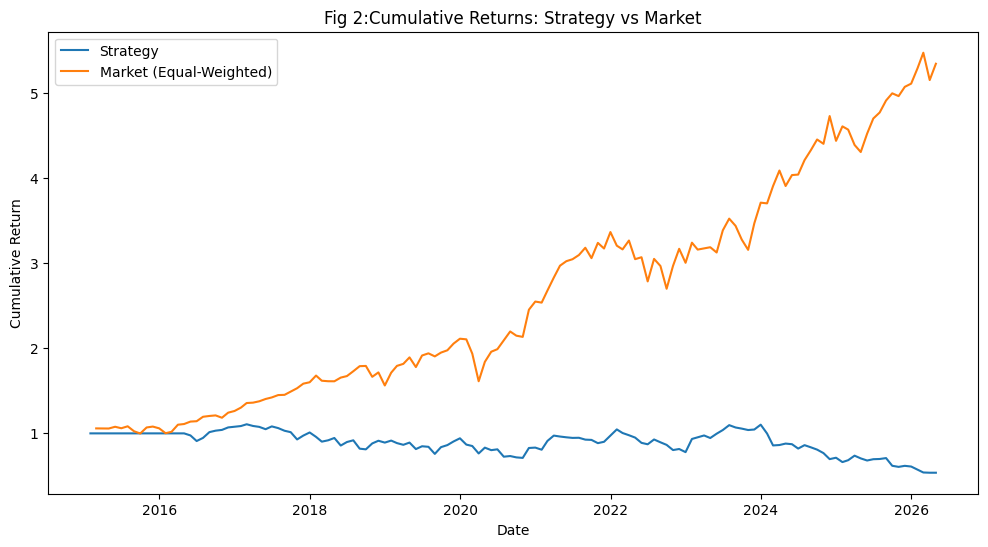

In [15]:
# plot cummulative market returns vs strategy returns as line plot
plt.figure(figsize=(12, 6))
plt.plot((1 + strat_returns).cumprod(), label='Strategy')
plt.plot((1 + market_returns).cumprod(), label='Market (Equal-Weighted)')
plt.title('Fig 2:Cumulative Returns: Strategy vs Market')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()


### Strat and Market Correlation

##### Fairly low, I think its good to assume my strategy mostly consists of pure ALPHA
##### However, we see later that draw downs are destroyers of my strat

In [16]:
(strat_returns.astype(float).corr(market_returns))

np.float64(0.25895504085158855)

### Max Draw down calculations

In [17]:
running_max = equity_curve.cummax()

drawdown = (equity_curve - running_max) / running_max

mdd = drawdown.min()

print("Max Drawdown:", mdd)

Max Drawdown: -0.5144916404903574


<Axes: title={'center': 'Drawdown'}>

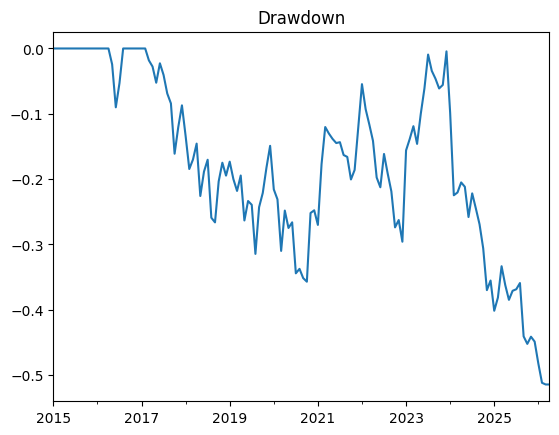

In [18]:
drawdown.plot(title="Drawdown")

##### Time in Drawdown

* Its pretty bad I know but this is exactly the area where risk control comes into play.
* We can say if the draw down passes a certain threshold, we should no longer trade with our current strat and maybe increase the short amount(short bottom 30%) and reduce long (long the top 5%).
* Or we can combined period of max drawdowns with other orthogonal strategy like reversal --> regime switching.

In [19]:
# Boolean: are we in drawdown?
underwater = drawdown < 0

# Count consecutive periods underwater
drawdown_duration = underwater.groupby((underwater != underwater.shift()).cumsum()).cumcount()

max_duration = drawdown_duration.max()

print("Max Drawdown Duration:", max_duration)

Max Drawdown Duration: 109


##### Peak to recovery duration

In [20]:
# Find peaks (where equity == running max)
peaks = equity_curve == running_max

# Track duration since last peak
duration = (~peaks).astype(int)

duration = duration.groupby(peaks.cumsum()).cumsum()

max_duration = duration.max()

print("Max Peak-to-Recovery Duration:", max_duration)

Max Peak-to-Recovery Duration: 110
